<font color='DarkBlue' size=+2><b>Комментарий</b></font><br>
<font color='DarkBlue'>Привет, 
<font color='DarkGreen'>👌 Зеленый текст &mdash; все отлично.</font><br>
<font color='DarkMagenta'>👉 Фиолетовый текст &mdash; углом.</font><br>
<font color='Red'>🛠 Красный текст &mdash;  </font><br><font color='DarkBlue'>Л есть.</font><br>



# Научно-исследовательская работа 

Выполнила студентка 5 курса педиатрического факультета ИвГМУ Рыжухина Татьяна Юрьевна



**Общая цель исследования**


Выявить закономерности, определяющие детский травматизм в Ивановской области.

**Задачи исследования**

1. По данным по травматизму определить 

**Примечание**


<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkMagenta'>👉 Было бы правильно добавить план исследования в описание проекта.</font>

**Раздел 1. Анализ исходных данных**

In [74]:
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as st
from scipy.stats import binom , norm
from scipy import stats as st
from math import sqrt
import requests
from io import BytesIO


In [79]:
url_2021 = "https://raw.github.com/Demon2205/Tatiana-s-science-work-/main/Журнал%202021.xlsx"
url_2022 = "https://raw.github.com/Demon2205/Tatiana-s-science-work-/main/Журнал%202022.xlsx"
url_2023 = "https://raw.github.com/Demon2205/Tatiana-s-science-work-/main/Журнал%202023.xlsx"
url_2024 = "https://raw.github.com/Demon2205/Tatiana-s-science-work-/main/Журнал%202024.xlsx"
url_2025 = "https://raw.github.com/Demon2205/Tatiana-s-science-work-/main/Журнал%202025.xlsx"

url_list = [url_2021,url_2022,url_2023,url_2024,url_2025]

In [80]:
dataframes = []
for i in url_list:
   response = requests.get(i)
   df_url = pd.read_excel(BytesIO(response.content))
   dataframes.append(df_url) 

In [81]:
df_2021 = dataframes[0]
df_2022= dataframes[1]
df_2023 = dataframes[2]
df_2024 = dataframes[3]
df_2025 = dataframes[4]

df=pd.concat([df_2021, df_2022,df_2023,df_2024,df_2025], ignore_index=True)


In [82]:
df

,№ п/п,№ и/б,Отделение,Дата поступления,Время поступления,"Фамилия, имя, отчество",Дата рождения,Возраст,Канал поступления,Профиль отделения,...,Дата перевода,Время перевода,Столбец1,койко-дни,Сосудистый доступ,Регионарная анестезия,Трансфузии,ЭКД,Примечания,Лечащий врач
0,1.0,1029.0,ДОТО,2020-09-24 00:00:00,16:10:00,Манукян Мариям,2012-04-15 00:00:00,8 г. 5 мес. 9 дн.,Из других больниц,ДОТО,...,2021-02-10 00:00:00,01:37:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.0,1106.0,ДХО-2,2020-12-02 00:00:00,11:40:00,Смирнов Илья,2020-12-01 00:00:00,0 г. 0 мес. 1 дн.,Из других больниц,ДХО-2,...,2021-01-31 00:00:00,12:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3.0,346.0,Неврология,2020-12-03 00:00:00,06:15:00,Федотов Максим,2019-05-28 00:00:00,1 г. 6 мес. 5 дн.,Доставлен СМП,Неврология,...,2021-02-08 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4.0,501.0,Педиатрия,2020-12-30 00:00:00,15:15:00,Палагутова Мира,2019-11-14 00:00:00,1 г. 1 мес. 16 дн.,Из других больниц,Педиатрия,...,2021-01-03 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5.0,494.0,Педиатрия,2020-12-30 00:00:00,15:20:00,Федотов Яромир,2009-09-18 00:00:00,11 г. 3 мес. 12 дн.,Из профильных отделений,Педиатрия,...,2021-01-03 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10823,NaN,NaN,NaN,NaN,NaN,NaN,NaT,0 г. 0 мес. 0 дн.,Доставлен_СМП,NaN,...,NaN,NaN,2505,0 г. 0 мес. 0 дн.,NaN,NaN,NaN,NaN,NaN,NaN
10824,NaN,NaN,NaN,NaN,NaN,NaN,NaT,0 г. 0 мес. 0 дн.,Доставлен_СМП,NaN,...,NaN,NaN,2506,0 г. 0 мес. 0 дн.,NaN,NaN,NaN,NaN,NaN,NaN
10825,NaN,NaN,NaN,NaN,NaN,NaN,NaT,0 г. 0 мес. 0 дн.,Доставлен_СМП,NaN,...,NaN,NaN,2507,0 г. 0 мес. 0 дн.,NaN,NaN,NaN,NaN,NaN,NaN
10826,NaN,NaN,NaN,NaN,NaN,NaN,NaT,0 г. 0 мес. 0 дн.,Доставлен_СМП,NaN,...,NaN,NaN,2508,0 г. 0 мес. 0 дн.,NaN,NaN,NaN,NaN,NaN,NaN


In [60]:
df = df.dropna(subset=['Отделение','Дата поступления','Время поступления','Возраст','Дата рождения'])
df = df.drop(['Примечания','Столбец1'], axis=1)

In [38]:
df.head(5)

,№ п/п,№ и/б,Отделение,Дата поступления,Время поступления,"Фамилия, имя, отчество",Дата рождения,Возраст,Канал поступления,Профиль отделения,...,Категория диагноза,Длительность ИВЛ,Сосудистый доступ,Регионарная анестезия,Трансфузии,ЭКД,Куда переведён,Дата перевода,Время перевода,койко-дни
0,1,10.0,Пед. паллиатив,2024-01-01,00:05:00,Кобликов Артем Денисович,2023-04-08,0 г. 8 мес. 24 дн.,Повторное_поступление,Пед. паллиатив,...,Болезни нервной системы и органов чувств,NaN,ЦВК,NaN,NaN,NaN,Пед. паллиатив,2024-01-30,23:55:00,0 г. 0 мес. 29 дн.
1,2,8.0,Пед. паллиатив,2024-01-01,00:05:00,Ишунина Екатерина Владимировна,2013-08-27,10 г. 4 мес. 5 дн.,Повторное_поступление,Пед. паллиатив,...,Болезни нервной системы и органов чувств,230.0,ЦВК,NaN,NaN,NaN,Прочее,2024-01-10,14:30:00,0 г. 0 мес. 9 дн.
2,3,12.0,Педиатрия,2024-01-01,04:30:00,Кудрявцев Никита Анатольевич,2008-08-08,15 г. 4 мес. 24 дн.,Доставлен_СМП,NaN,...,Отравления,NaN,Периф. вен. кат.,NaN,NaN,NaN,Педиатрия,2024-01-01,12:00:00,0 г. 0 мес. 0 дн.
3,4,11.0,Педиатрия,2024-01-01,04:15:00,Кузнецов Ярослав Александрович,2008-11-11,15 г. 1 мес. 21 дн.,Доставлен_СМП,NaN,...,Отравления,NaN,Периф. вен. кат.,NaN,NaN,NaN,Педиатрия,2024-01-01,15:00:00,0 г. 0 мес. 0 дн.
4,5,6.0,ДХО,2024-01-03,17:00:00,Кудряшова Елизавета Евгеньевна,2009-11-29,14 г. 1 мес. 5 дн.,Из_операционной,ДХО,...,Болезни органов пищеварения,NaN,ЦВК,Эпидур. анест.,NaN,NaN,ДХО,2024-01-07,12:00:00,0 г. 0 мес. 4 дн.


In [39]:
df['Категория диагноза']

0      Болезни нервной системы и органов чувств
1      Болезни нервной системы и органов чувств
2                                    Отравления
3                                    Отравления
4                   Болезни органов пищеварения
                         ...                   
521                 Болезни органов пищеварения
522           Травма сочетанная и изолированная
523    Болезни нервной системы и органов чувств
524                             Ожоговая травма
525                     Болезни органов дыхания
Name: Категория диагноза, Length: 525, dtype: object

In [6]:
data1 = df.pivot_table(index='Категория диагноза', values='Отделение',aggfunc='count')
data1.plot(kind = 'bar', figsize = (10,8), rot = 0, grid=True, fontsize = 15, stacked=True, colormap='jet')
plt.title('Доля оттока клиентов по городам', fontsize=15, color='Black');
plt.xlabel('', fontsize=15,rotation = 90),;
plt.ylabel('Доля оттока', rotation = 90,fontsize=15,rotation = 90);
plt.xticks(rotation=90);
plt.legend('',frameon=False);

SyntaxError: keyword argument repeated (<ipython-input-6-c6cd580e25b7>, line 5)

In [73]:
df1 = df.groupby(['Категория диагноза']).agg({'Отделение': 'count' }
                                                    )

df1 = df1.reset_index()
fig = px.bar(df1, x="Категория диагноза", y="Отделение"
                          ,width = 1000, height = 700, color='Категория диагноза')

fig.update_layout(
    title="Количество обьектов общественного питания по категориям",
    xaxis_title="Категория заведений",
    yaxis_title="Количество заведений",
    legend_title = "Категория",
        font=dict(
        family="Courier New, monospace",
        size=18
        
    )
)

fig.show()

,Отделение,Дата поступления,Время поступления,Дата рождения,Возраст,Канал поступления,Профиль отделения,Адрес регистраци,Диагноз при поступлении в ОРИТ,Категория диагноза,Длительность ИВЛ,Сосудистый доступ,Регионарная анестезия,Трансфузии,ЭКД,Куда переведён,Дата перевода,Время перевода,койко-дни
0,Пед. паллиатив,2024-01-01,00:05:00,2023-04-08,0 г. 8 мес. 24 дн.,Повторное_поступление,Пед. паллиатив,Вичуга,Органическое поражение ЦНС,Болезни нервной системы и органов чувств,NaN,ЦВК,NaN,NaN,NaN,Пед. паллиатив,2024-01-30,23:55:00,0 г. 0 мес. 29 дн.
1,Пед. паллиатив,2024-01-01,00:05:00,2013-08-27,10 г. 4 мес. 5 дн.,Повторное_поступление,Пед. паллиатив,Иваново 2 Сременная 6,"Оргаеическое поражение ЦНС, пневмония",Болезни нервной системы и органов чувств,230.0,ЦВК,NaN,NaN,NaN,Прочее,2024-01-10,14:30:00,0 г. 0 мес. 9 дн.
2,Педиатрия,2024-01-01,04:30:00,2008-08-08,15 г. 4 мес. 24 дн.,Доставлен_СМП,NaN,Иваново,Отравление суррогатами алкоголя,Отравления,NaN,Периф. вен. кат.,NaN,NaN,NaN,Педиатрия,2024-01-01,12:00:00,0 г. 0 мес. 0 дн.
3,Педиатрия,2024-01-01,04:15:00,2008-11-11,15 г. 1 мес. 21 дн.,Доставлен_СМП,NaN,Иваново,отравление суррогатами алкоголя,Отравления,NaN,Периф. вен. кат.,NaN,NaN,NaN,Педиатрия,2024-01-01,15:00:00,0 г. 0 мес. 0 дн.
4,ДХО,2024-01-03,17:00:00,2009-11-29,14 г. 1 мес. 5 дн.,Из_операционной,ДХО,иваново дюковская 25-2,аппендицит разлитой перитнит,Болезни органов пищеварения,NaN,ЦВК,Эпидур. анест.,NaN,NaN,ДХО,2024-01-07,12:00:00,0 г. 0 мес. 4 дн.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2505,NaN,NaT,NaN,NaT,0 г. 0 мес. 0 дн.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,0 г. 0 мес. 0 дн.
2506,NaN,NaT,NaN,NaT,0 г. 0 мес. 0 дн.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,0 г. 0 мес. 0 дн.
2507,NaN,NaT,NaN,NaT,0 г. 0 мес. 0 дн.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,0 г. 0 мес. 0 дн.
2508,NaN,NaT,NaN,NaT,0 г. 0 мес. 0 дн.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,0 г. 0 мес. 0 дн.


In [39]:
for col in df:
 print(df[col].unique()) # и на уникальные значения


['Пед. паллиатив' 'Педиатрия' 'ДХО' 'ДОТО' 'Пульмо' 'Неврология' 'дхо'
 'ОПНН' 'Нефро' 'пульмо' nan]
<DatetimeArray>
['2024-01-01 00:00:00', '2024-01-03 00:00:00', '2024-01-04 00:00:00',
 '2024-01-05 00:00:00', '2024-01-07 00:00:00', '2024-01-10 00:00:00',
 '2024-01-11 00:00:00', '2023-01-11 00:00:00', '2024-01-13 00:00:00',
 '2024-01-14 00:00:00',
 ...
 '2024-12-19 00:00:00', '2024-12-20 00:00:00', '2024-12-21 00:00:00',
 '2024-12-24 00:00:00', '2024-12-25 00:00:00', '2024-12-26 00:00:00',
 '2024-12-27 00:00:00', '2024-12-28 00:00:00', '2024-12-30 00:00:00',
                 'NaT']
Length: 277, dtype: datetime64[ns]
[datetime.time(0, 5) datetime.time(4, 30) datetime.time(4, 15)
 datetime.time(17, 0) datetime.time(16, 55) datetime.time(0, 10)
 datetime.time(17, 10) datetime.time(19, 50) datetime.time(17, 30)
 datetime.time(23, 0) datetime.time(1, 0) datetime.time(6, 45)
 datetime.time(22, 55) datetime.time(22, 20) datetime.time(16, 20)
 datetime.time(14, 15) datetime.time(14, 0) dateti

**Вывод по разделу 1**

Датафрейм содержит 10 столбцов, 16714 строки. 


Описание данных
Name — название игры


Platform — платформа


Year_of_Release — год выпуска


Genre — жанр игры


NA_sales — продажи в Северной Америке (миллионы проданных копий)


EU_sales — продажи в Европе (миллионы проданных копий)


JP_sales — продажи в Японии (миллионы проданных копий)


Other_sales — продажи в других странах (миллионы проданных копий)


Critic_Score — оценка критиков (максимум 100)


User_Score — оценка пользователей (максимум 10)


Rating — рейтинг от организации ESRB (англ. Entertainment Software Rating Board). Эта ассоциация определяет рейтинг компьютерных игр и присваивает им подходящую возрастную категорию.


Данные год имеют пропуски. Тип данных в столбцах "Год выпуска", "пользовательская оценки" не соответсвуют логике. Необходима замена. 


Необходима предобработка данных

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkGreen'>👌 Хорошо, изучили данные для предобработки.</font>

**Раздел 2. Предобработка исходных данных**

In [6]:
print(df_orig['Year_of_Release'].tail()) # смотрим хвосты

16710    2016.0
16711    2006.0
16712    2016.0
16713    2003.0
16714    2016.0
Name: Year_of_Release, dtype: float64


In [ ]:
r

Начнем с даты релиза игры, приведем строковый формат в формат Datetime

In [7]:
df_orig['Year_of_Release'] = pd.to_datetime(df_orig['Year_of_Release'], format='%Y') # Меняем тип колонки
df_orig['Year_of_Release']

0       2006-01-01
1       1985-01-01
2       2008-01-01
3       2009-01-01
4       1996-01-01
           ...    
16710   2016-01-01
16711   2006-01-01
16712   2016-01-01
16713   2003-01-01
16714   2016-01-01
Name: Year_of_Release, Length: 16715, dtype: datetime64[ns]

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkMagenta'>👉 Не понятно, зачем мы переводим в дату? Проще было в тип `int` и памяти меньше занимает.</font>

Добаляем "Огонь функцию по проверки колличества пропусков в датафрейме"

In [30]:
# check
# пропущенные значения бары

def pass_value_barh(dfg):
    try:
        (
            (dfg.isna().mean()*100)
            .to_frame()
            .rename(columns = {0:'space'})
            .query('space > 0')
            .sort_values(by = 'space', ascending = True)
            .plot(kind = 'barh', figsize = (19,6), rot = 0, legend = False, fontsize = 16)
            .title('Пропущенные значения, %' + "\n", fontsize=22, color='SteelBlue')
             .xlabel('Процент пропусков', fontsize=22)
            .ylabel('Столбцы с пропусками')
            .xlim(0, 100)  
        );    
    except:
        print('пропусков не осталось :) или произошла ошибка в первой части функции ')

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkGreen'>👌 Свои функции для выполнения повторяющихся операций - это короткий код и показатель профессионализма. 👍</font>

Оцениваем кол-во пропусков

пропусков не осталось :) или произошла ошибка в первой части функции 


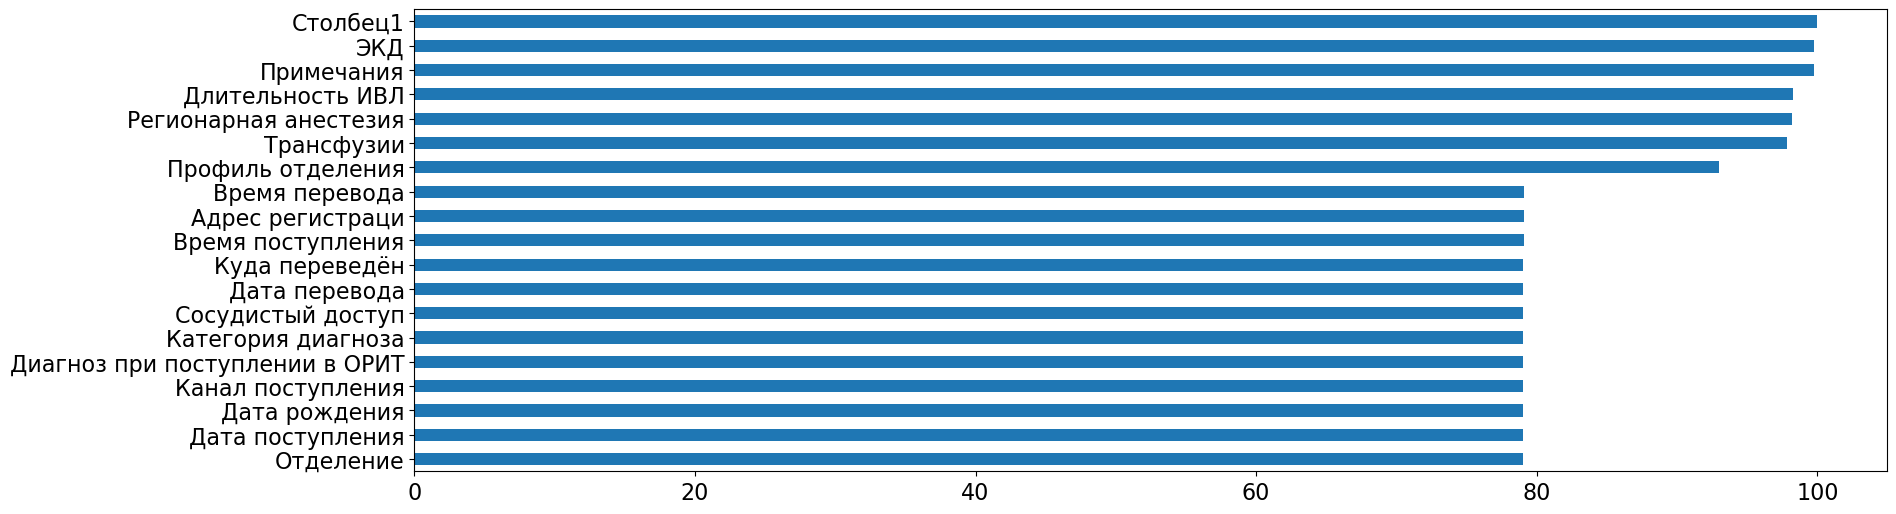

In [31]:
pass_value_barh(df)

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='Red'>🛠 Визуализация данных графиками и диаграммами подразумевает подписи всех осей и название графика  на русском языке, при необходимости наличие меток. Это относится ко всем графикам/диаграммам проекта и является критической ошибкой.</font>

Печаль-беда. Половина оценок критиков отсутвует, как и рейтинга по возрасту, так и пользовательских оценок. До 5 % нет года релиза игры. В приницпе. от этих 5 % можно избавиться

In [10]:
df_orig = df_orig.dropna(subset=['Year_of_Release'])

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkGreen'>👌 Правильное решение по удалению пропусков в годах релиза. Хорошо, что было проверено количество пропусков.</font>

пропусков не осталось :) или произошла ошибка в первой части функции 


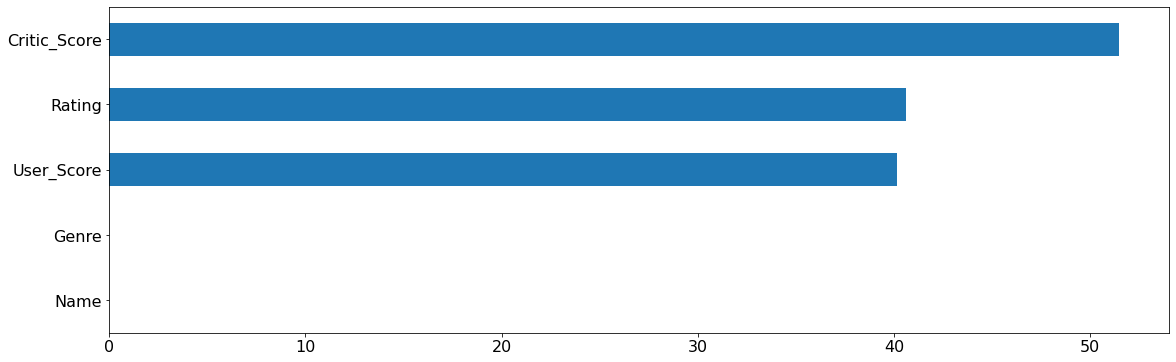

In [11]:
pass_value_barh(df_orig)

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='Red'>🛠 Диаграмма не оформлена необходимым образом. Здесь и далее в проекте.<br>Если есть с этим трудности, то следует обратиться за помощью к преподавателю.</font>

Из оставшихся пропусков можно попытаться заполнить пропуски по возрастному рейтингу, так как он по годам не меняется. Пропуски оценок пользователей по годам, считаю заполнять бесмысленно.

In [12]:
df_orig['User_Score'].unique()

array(['8', nan, '8.3', '8.5', '6.6', '8.4', '8.6', '7.7', '6.3', '7.4',
       '8.2', '9', '7.9', '8.1', '8.7', '7.1', '3.4', '5.3', '4.8', '3.2',
       '8.9', '6.4', '7.8', '7.5', '2.6', '7.2', '9.2', '7', '7.3', '4.3',
       '7.6', '5.7', '5', '9.1', '6.5', 'tbd', '8.8', '6.9', '9.4', '6.8',
       '6.1', '6.7', '5.4', '4', '4.9', '4.5', '9.3', '6.2', '4.2', '6',
       '3.7', '4.1', '5.8', '5.6', '5.5', '4.4', '4.6', '5.9', '3.9',
       '3.1', '2.9', '5.2', '3.3', '4.7', '5.1', '3.5', '2.5', '1.9', '3',
       '2.7', '2.2', '2', '9.5', '2.1', '3.6', '2.8', '1.8', '3.8', '0',
       '1.6', '9.6', '2.4', '1.7', '1.1', '0.3', '1.5', '0.7', '1.2',
       '2.3', '0.5', '1.3', '0.2', '0.6', '1.4', '0.9', '1', '9.7'],
      dtype=object)

In [13]:
df_orig['User_Score'].replace('tbd', np.NaN, inplace=True)  # избавляемся от пропусков и меняем тип данных
df_orig['User_Score'] = pd.to_numeric(df_orig['User_Score'], errors='coerce')
pd.options.mode.chained_assignment = None
df_orig['User_Score']

/opt/conda/lib/python3.9/site-packages/pandas/core/series.py:4509: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().replace(
/tmp/ipykernel_306/1190532770.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_orig['User_Score'] = pd.to_numeric(df_orig['User_Score'], errors='coerce')


0        8.0
1        NaN
2        8.3
3        8.0
4        NaN
        ... 
16710    NaN
16711    NaN
16712    NaN
16713    NaN
16714    NaN
Name: User_Score, Length: 16446, dtype: float64

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkGreen'>👌 Правильно сделана замена "tbd" на NaN. Это практически аналог пропусков.</font><br>
<font color='DarkGreen'>👌 Когда выскакивают предупреждения, это означает, что в будущей новой версии библиотеки применяемый метод обработки будет не применим. Если мы планируем данный код использовать в будущем, то надо разобраться и изменить код. Если нам он в будущем не понадобится, то можно принудительно запретить вывод предупреждений вставив в ячейку с библиотеками вот такой код: <br>`pd.set_option('chained_assignment', None)` или такой: <br></font>
`import warnings`<br>
`warnings.filterwarnings("ignore")`

In [14]:
df_orig = df_orig.rename(columns = lambda x: str.lower(x)) # назная столбцов к единому стилю
df_orig.head(10)

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006-01-01,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E
1,Super Mario Bros.,NES,1985-01-01,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008-01-01,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009-01-01,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E
4,Pokemon Red/Pokemon Blue,GB,1996-01-01,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989-01-01,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
6,New Super Mario Bros.,DS,2006-01-01,Platform,11.28,9.14,6.50,2.88,89.0,8.5,E
7,Wii Play,Wii,2006-01-01,Misc,13.96,9.18,2.93,2.84,58.0,6.6,E
8,New Super Mario Bros. Wii,Wii,2009-01-01,Platform,14.44,6.94,4.70,2.24,87.0,8.4,E
9,Duck Hunt,NES,1984-01-01,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN


<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkGreen'>👌 Хорошо! Приводим названия колонок к общепринятому стилю. 😉 <br>
А можно просто методом вот так:</font><br>
`df.columns = df.columns.str.lower()`

In [15]:
df_orig[df_orig.duplicated(['name','genre'])] # смотрим дубликаты

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
23,Grand Theft Auto V,X360,2013-01-01,Action,9.66,5.14,0.06,1.41,97.0,8.1,M
35,Call of Duty: Black Ops II,X360,2012-01-01,Shooter,8.25,4.24,0.07,1.12,83.0,4.8,M
37,Call of Duty: Modern Warfare 3,PS3,2011-01-01,Shooter,5.54,5.73,0.49,1.57,88.0,3.2,M
41,Call of Duty: Black Ops,PS3,2010-01-01,Shooter,5.99,4.37,0.48,1.79,88.0,6.4,M
42,Grand Theft Auto V,PS4,2014-01-01,Action,3.96,6.31,0.38,1.97,97.0,8.3,M
...,...,...,...,...,...,...,...,...,...,...,...
16706,Men in Black II: Alien Escape,GC,2003-01-01,Shooter,0.01,0.00,0.00,0.00,NaN,NaN,T
16709,SCORE International Baja 1000: The Official Game,PS2,2008-01-01,Racing,0.00,0.00,0.00,0.00,NaN,NaN,NaN
16710,Samurai Warriors: Sanada Maru,PS3,2016-01-01,Action,0.00,0.00,0.01,0.00,NaN,NaN,NaN
16713,Spirits & Spells,GBA,2003-01-01,Platform,0.01,0.00,0.00,0.00,NaN,NaN,NaN


<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='Red'>🛠 Просмотрел весь раздел, но не нашел проверки явных дубликатов. Если мы это сделали, но потом код удалили, то это не совсем правильно, пусть все знают, что мы тщательно анализируем данные.</font><br>
<font color='Red'>🛠 Так же не произведена проверка неявных дубликатов и не принято решение по их обработке. Данная проверка является составной частью первичного анализа данных. Проверять лучше по имени, платформе и году релиза одновременно.</font>

Специально оставляю закоментрованный. Пытался написаль функцию поиска похожих строк по ключевым славам, чтобы выставить рейтинг. Не получилось. Попытки оставил закоментированными

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkMagenta'>👉 И это было бы ошибкой.</font>

In [16]:
#def similarity(s1, s2):
  #normalized1 = s1.lower()
  #normalized2 = s2.lower()
  #matcher = difflib.SequenceMatcher(None, normalized1, normalized2)
  #return matcher.ratio()

In [17]:
#df_orig['rating'].unique()
#df_orig['rating'].isna()
#df_orig['rating'] = df_orig['rating'].fillna('NET')

In [18]:
#df_orig['rating'].unique()

In [19]:
#from rapidfuzz import fuzz

#def lev_check(text, target):
  #  """Функция фналогична косинусному сходству только без векторизации"""
  #  score = 0
  #  pos = 0
   # assert len(text) > len(target)
   # for i in range(len(text) - len(target)):
    #    # делим метрику на 100, т.к. данная метрика находится в пределах от 0 до 100
       # current_score = fuzz.ratio(text[i: i + len(target)], target)/100
        #if current_score > score:
         #   score = current_score
           # pos = i
    #return score, text[pos: pos + len(target)]

In [20]:
#np.any(df_orig['rating'].isna().values)

#N = range(len(df_orig['rating']))

#for i in N:
    #if i == 'M':
    #j1 = df_orig.iloc [i]['rating']
    #if j1 == 'NET':
        #j = 1
        #for j in N:    
           #print(i)
            #j2 = df_orig.iloc [j]['rating']      
            #if similarity(j1, j2) > 0.3:      
                #df_orig.at[i,'rating'] = j2
            #else: continue

Считаем суммарные продажи во всех регионах 


In [21]:
df_orig['sales_sum'] = df_orig['na_sales']+df_orig['eu_sales']+df_orig['jp_sales']
df_orig['sales_sum']

0        74.09
1        39.47
2        32.23
3        29.82
4        30.38
         ...  
16710     0.01
16711     0.01
16712     0.01
16713     0.01
16714     0.01
Name: sales_sum, Length: 16446, dtype: float64

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='Red'>🛠 Забыли добавить в суммарные продажи other_sales.</font>

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='Red'>🛠 Вот, что написано в задании: <br><b>
Опишите причины, которые могли привести к пропускам</b> <br>А это не сделано.</font>

**Вывод по разделу 2**

Исходные данные имеют большую долю пропусков, с которыми, к сожалению ничего не сделать. Кроме возрастного рейтинга, но я не знаю как его привести. Столбцы переименованы, пропуски по годам удалены, т.к. их немного

In [46]:
# Комментарий ревьюера
# Посмотрим, что осталось
temp = df_orig.copy() 
list_c = ['name', 'platform', 'year_of_release', 'genre', 'critic_score', 'user_score', 'rating']
print(temp.info())
for col_l in list_c:
  print('-'* 25)
  print(col_l, temp[col_l].sort_values().unique())
  print(col_l,': кол-во NaN',temp[col_l].isna().sum(),
        ', процент NaN', round(temp[col_l].isna().mean()*100,2),'%') 

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16446 entries, 0 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   name             16444 non-null  object        
 1   platform         16446 non-null  object        
 2   year_of_release  16446 non-null  datetime64[ns]
 3   genre            16444 non-null  object        
 4   na_sales         16446 non-null  float64       
 5   eu_sales         16446 non-null  float64       
 6   jp_sales         16446 non-null  float64       
 7   other_sales      16446 non-null  float64       
 8   critic_score     7983 non-null   float64       
 9   user_score       7463 non-null   float64       
 10  rating           9768 non-null   object        
 11  sales_sum        16446 non-null  float64       
dtypes: datetime64[ns](1), float64(7), object(4)
memory usage: 1.6+ MB
None
-------------------------
name [' Beyblade Burst' ' Fire Emblem Fates' " 

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkMagenta'>👉 Не совсем понятное решение, всего два пропуска в колонках `name` и `genre`, да еще в этих строках пропуски по отзывам и рейтингу. Может проще удалить?</font><br>
<font color='DarkMagenta'>👉 Я бы порекомендовал посмотреть в инете, что означает рейтинг ESRB. И пропуски в этой колонке не являются просто ошибкой заполнения данных, а несут определенную информацию. Что бы проанализировать ее, на пропуски следует поставить заглушку. Но может это мы сделаем позже? Ладно, будем смотреть дальше. </font>

<font color='DarkBlue'><b>Комментарий ревьюера: Глоссарий</b></font><br>
<font color='DarkGreen'>👌 В контексте анализа и предобработки датасета часто используютется термин: <b>Заглушка</b>. <br>Из словаря: "Заглушка — приспособление для закрывания отверстия наглухо." <br>В нашем контексте закрытие пропуска в датасете каким-то значением, совпадающим по типу с данными колонки таблицы. Как правило, для числовых данных заглушка должна быть вне диапазона значений колонки. При анализе по данной колонке заглушка или фильтруется, или включается в анализ, если сам пропуск не является ошибкой сбора данных и несет какой-то признак. <br>Частая ошибка, когда заглушке присваивается числовое значение, например `0`, а в данных колонки присутствуют символьные значения `'0'`, то при преобразовании к числовому типу произойдет слияние значимых данных таблицы и заглушки.</font>

**Раздел 3. Исследовательский анализ данных**

Задачи:

 - определить сколько игр выпускалось в разные годы. Уточнить важны ли данные за все периоды?
 - определить как менялись продажи по платформам. Выберать платформы с наибольшими суммарными продажами и постройть распределение по годам. Определить за какой характерный срок появляются новые и исчезают старые платформы?
 - использовать данные за соответствующий актуальный период (основной фактор — эти данные помогут построить прогноз на 2017 год) Данные за предыдущие годы не учитывать
 -  определить какие платформы лидируют по продажам, растут или падают? Выберать несколько потенциально прибыльных платформ.
 -  постройтт график «ящик с усами» по глобальным продажам игр в разбивке по платформам. Описать результат.
 -  определисть, как влияют на продажи внутри одной популярной платформы отзывы пользователей и критиков. Постройть диаграмму рассеяния и посчитайть корреляцию между отзывами и продажами. Сформулировать выводы.
 - соотнесити выводы с продажами игр на других платформах.
 - посмотреть на общее распределение игр по жанрам. Что можно сказать о самых прибыльных жанрах? Выделяются ли жанры с высокими и низкими продажами?




 - определить сколько игр выпускалось в разные годы. Уточнить важны ли данные за все периоды?

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='Red'>🛠 Обращаю внимание, что проект не имеет необходимого оформления. Проект должен иметь структру с разделами и подразделами исследования, с формулировкой промежуточной задачи, с комментариями, что мы делаем, что получили. Каждый раздел/подраздел должен начинаться с названия, отражающего его содержание, и решаемой задачи, заканчиваться промежуточным выводом. Отдельные строки кода выполняющие необходимые преобразования должны находиться в отдельных исполняемых ячейках, комментарии и промежуточные выводы должны размещаться в отдельных ячейках 'markdown'. Необходимо пройти по шагам проекта и добавить необходимые элементы. Подробнее описано в "Полезных инструкциях для учёбы".</font>

In [22]:
df_year_game = df_orig.groupby('year_of_release').agg({'name' : 'count'})
df_year_game

,name
year_of_release,
1980-01-01,9
1981-01-01,46
1982-01-01,36
1983-01-01,17
1984-01-01,14
1985-01-01,14
1986-01-01,21
1987-01-01,16
1988-01-01,15


In [23]:
df_orig['platform'].unique()

array(['Wii', 'NES', 'GB', 'DS', 'X360', 'PS3', 'PS2', 'SNES', 'GBA',
       'PS4', '3DS', 'N64', 'PS', 'XB', 'PC', '2600', 'PSP', 'XOne',
       'WiiU', 'GC', 'GEN', 'DC', 'PSV', 'SAT', 'SCD', 'WS', 'NG', 'TG16',
       '3DO', 'GG', 'PCFX'], dtype=object)

Данные до 200 года я бы не учитывал. Пока это перваначальный вывод


определить как менялись продажи по платформам. Выбрать платформы с наибольшими суммарными продажами и постройть распределение по годам. Определить за какой характерный срок появляются новые и исчезают старые платформы

In [24]:
df_pl = df_orig.groupby('platform').agg({'sales_sum' : 'sum'})
df_pl['sales_sum'].sort_values(ascending=False)
df_pl


,sales_sum
platform,
2600,85.64
3DO,0.10
3DS,244.54
DC,15.68
DS,743.74
GB,246.27
GBA,305.27
GC,191.60
GEN,29.80


<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkMagenta'>👉 При анализе принято визуализировать результаты в виде графиков или диаграмм. Таблицы малоинформативны и не наглядны. Можно вот так:</font>
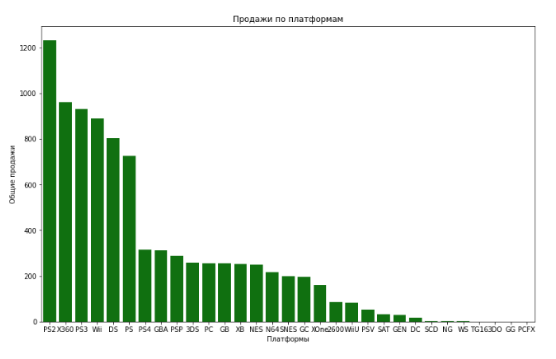

In [25]:
df_pl.query('sales_sum > 100') # ограничиваем по прибыли

,sales_sum
platform,
3DS,244.54
DS,743.74
GB,246.27
GBA,305.27
GC,191.60
N64,213.70
NES,245.74
PC,233.88
PS,686.89


In [26]:
df_pl = df_pl.query('sales_sum > 100') # тут тоже
df_pl['platform'] = df_pl.index
df_pl.reset_index(drop= True , inplace= True )
df_pl

,sales_sum,platform
0,244.54,3DS
1,743.74,DS
2,246.27,GB
3,305.27,GBA
4,191.60,GC
5,213.70,N64
6,245.74,NES
7,233.88,PC
8,686.89,PS
9,1043.09,PS2


<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='Red'>🛠 Вот, что написано в задании: <br><b>Посмотрите, как менялись продажи по платформам. Выберите платформы с наибольшими суммарными продажами и постройте распределение по годам. За какой характерный срок появляются новые и исчезают старые платформы?</b> <br>Срок жизни платформ не определен, промежуточных выводов анализа не сделано.</font>

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='Red'>🛠 Нет названия подраздела и не сформулирована задача. Не понятно, что и зачем делаем далее.</font>

In [27]:
df_pl_year = df_orig.merge(df_pl['platform'], on='platform',how='outer')
df_pl_year['year_of_release'] = df_pl_year['year_of_release'].dt.year
df_orig_off_filt = df_pl_year
df_pl_year = df_pl_year.query('year_of_release >= 2012') # выделяем данные только с 2012 года. Честно, подсмотрел, у коллег
df_pl_year['platform'].value_counts() # А так, нет смысла для рекланой кампании 2017 года сравнивать старые игры

PS3     493
PSV     411
3DS     396
PS4     392
X360    292
PC      250
XOne    247
PSP     173
WiiU    147
Wii      54
DS       31
Name: platform, dtype: int64

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkGreen'>👌 Правильно выбран актуальный период. 👍 Сейчас в наше динамичное время в бизнесе уже используются для прогноза периоды в 2-3 года.</font>

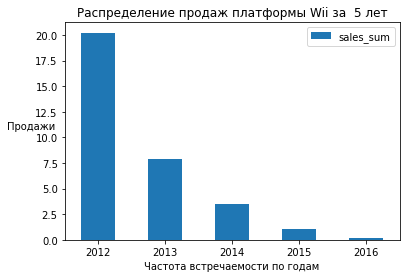

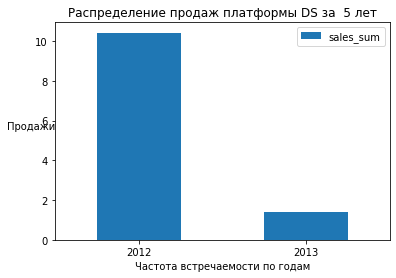

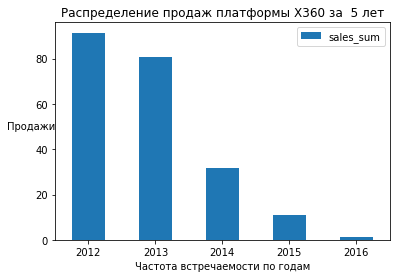

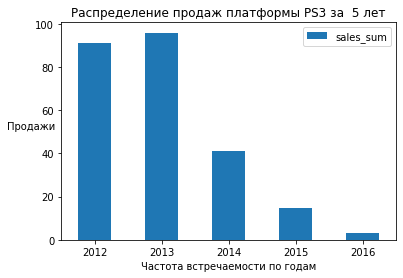

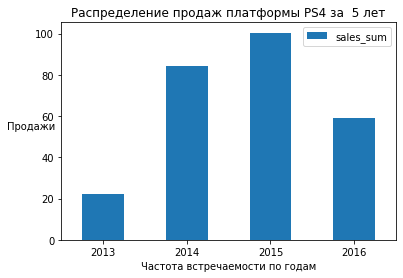

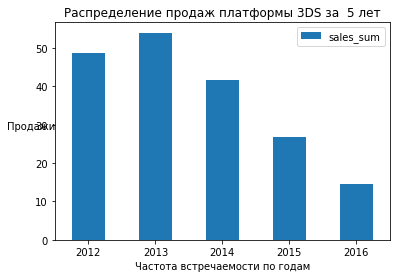

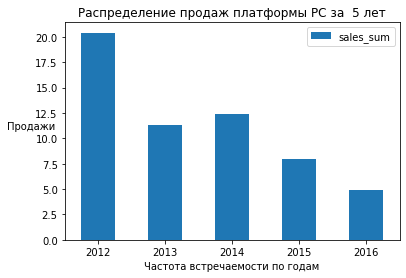

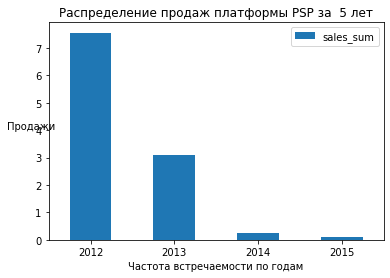

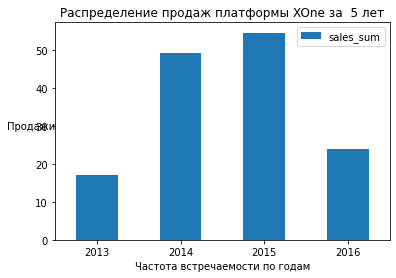

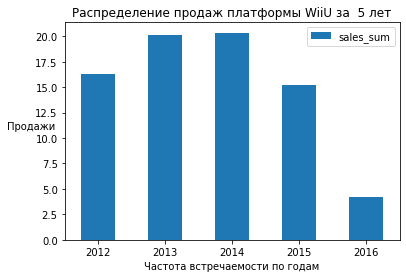

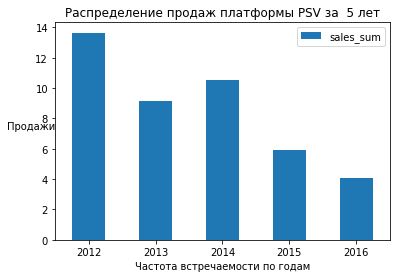

In [28]:
for type_consol in df_pl_year['platform'].unique():  # Строим гистрграммы продаж по платформам и по годам
    df_pl_year.query('platform == @type_consol').pivot_table(index='year_of_release', values='sales_sum'
                        , aggfunc={"sales_sum" : 'sum'},
                        fill_value=0).plot.bar();

    plt.title(f'Распределение продаж платформы {type_consol} за  5 лет');
    plt.xlabel('Частота встречаемости по годам');
    plt.ylabel('Продажи',rotation=0);
    plt.xticks(rotation=0);

       

Стоит отметить, что в лидерах оказались WiiU, PS4 и XOne. У данных платформ сохраняется тенденция к росту либо падение продаж не так велико, по сравнению с остальными. На данных платформах и созредоточим далее исследование

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='Red'>🛠 Что написано в задании: <br><b>Выберите несколько потенциально прибыльных платформ.</b> <br>А это сделано не корректно. Платформа WiiU практически ушла с рынка.</font>

In [29]:
best_consol = pd.Series(['WiiU','PS4','XOne'])
best_consol

0    WiiU
1     PS4
2    XOne
dtype: object

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='Red'>🛠 Нет названия подраздела и не сформулирована задача.</font>

(0.0, 8.0)

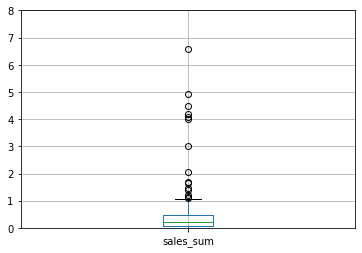

In [30]:
df_pl_year.query('platform == "WiiU"').boxplot(column=['sales_sum']) # Строим барплот
plt.ylim(0, 8)

(0.0, 13.0)

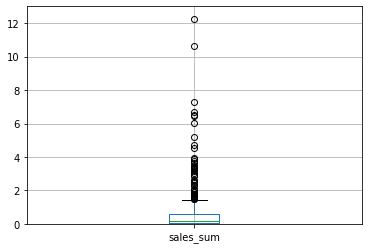

In [31]:
df_pl_year.query('platform == "PS4"').boxplot(column=['sales_sum']) # Строим барплот
plt.ylim(0, 13)

(0.0, 8.0)

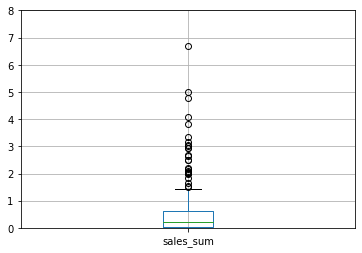

In [32]:
df_pl_year.query('platform == "XOne"').boxplot(column=['sales_sum']) # Строим барплот
plt.ylim(0, 8)

Дофига выбросов. Но тут большую роль играют пропуски, а с ними ничего не сделать (

(0.0, 13.0)

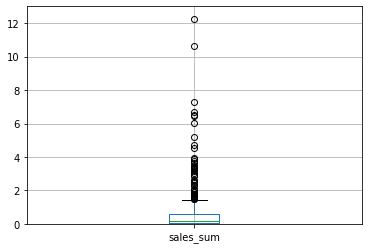

In [33]:
df_pl_year.query('platform == "PS4"').boxplot(column=['sales_sum']) # Строим барплот
plt.ylim(0, 13)

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='Red'>🛠 Почему строим диаграммы размаха не по всем платформам актуального периода? В задании топ-платформы не требуются, предполагаются все за актуальный период. Таким образом можно потерять значимую информацию. <br>Видимо, ввело в заблуждение предыдущее задание, где надо было определить лидеров. Но в заданиях на проект отдельно указывается, где необходимо анализировать топ.<br> Всегда при анализе следует использовать все данные, а потом можно их фильтровать от лишней информации.<br>А диаграммы размаха надо строить на одной координатной сетке в двух видах, в полном, со всеми выбросами и масштабированном с крупными боксплотами. Для вывода только нижней части boxplot-ов необходимо использовать параметр ylim. Примерно вот так:</font>
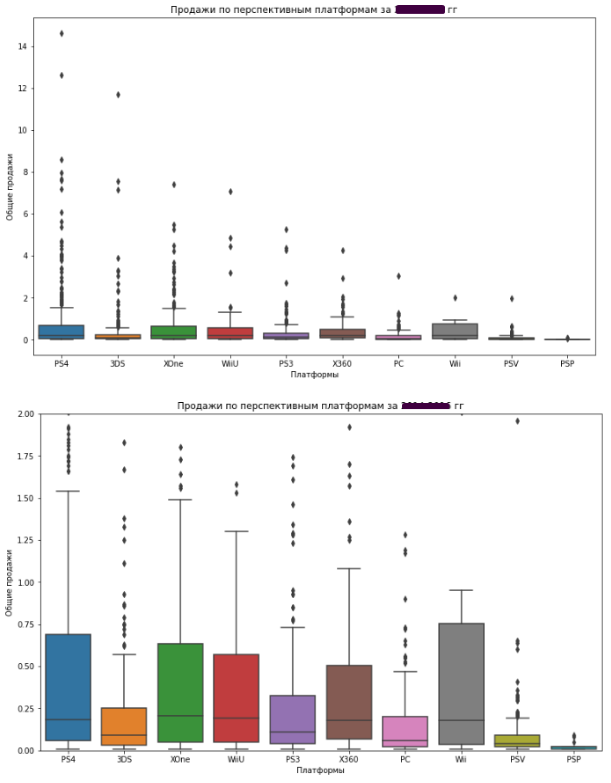

Аналогично

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='Red'>🛠 Нет названия подраздела и не сформулирована задача.</font>

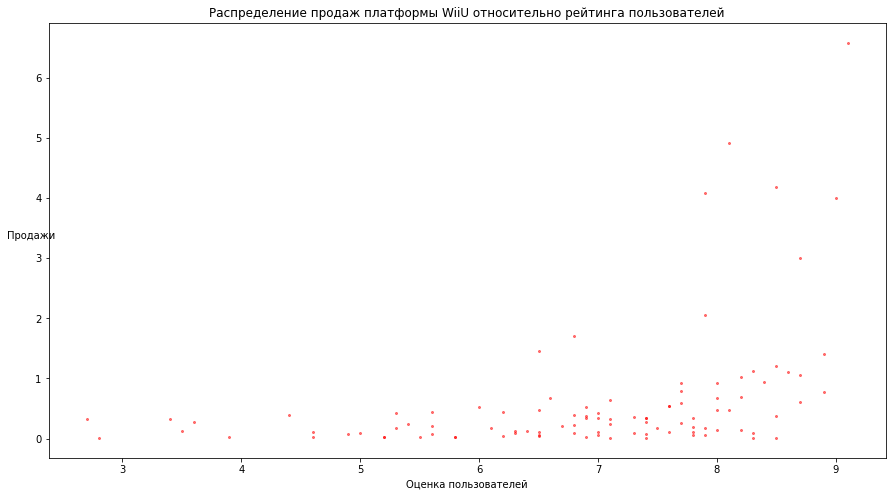

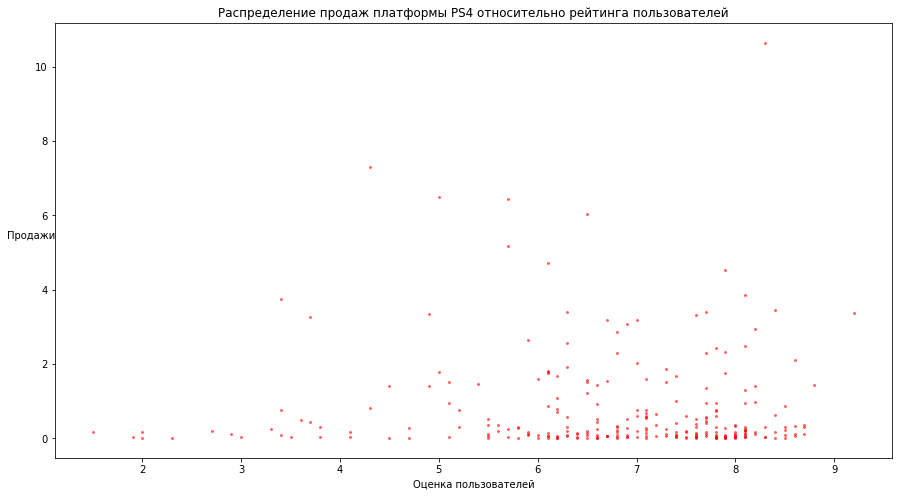

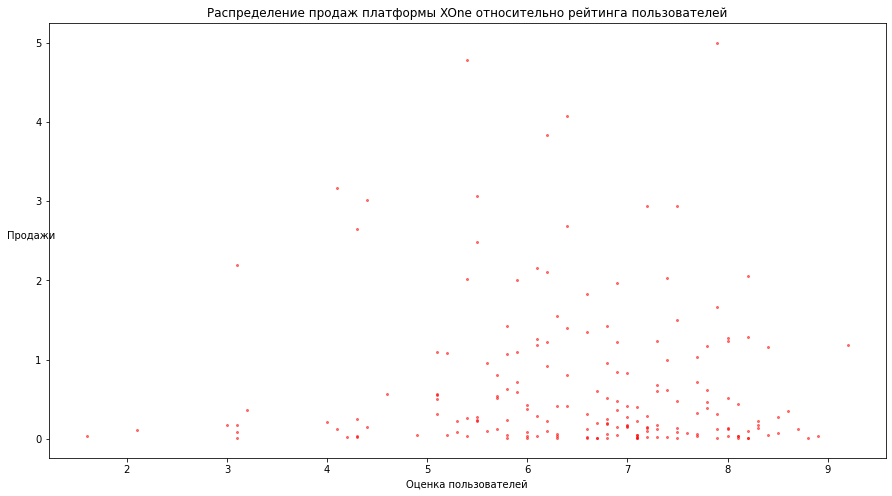

In [34]:
for type_consol in best_consol: # Смотрим продажи выбранных консолей по годам
    df_pl_year[df_pl_year['platform'] == type_consol].plot(kind='scatter', 
        y='sales_sum' , x='user_score', alpha=0.5, figsize=(15,8), c = 'r', s = 4)
    plt.title(f'Распределение продаж платформы {type_consol} относительно рейтинга пользователей');
    plt.xlabel('Оценка пользователей');
    plt.ylabel('Продажи',rotation=0);
    plt.xticks(rotation=0);

Покупающие Вии пользователи, явно довольны. Рейтинги растут вместе с продажами. По Соньке и Иксбоксу ситуация схожая, но продажи велики и при низком рейтинге. Как вариант вияет "раскрученность" бренда. Человек купил, потому что "круто", но ему не понравилось

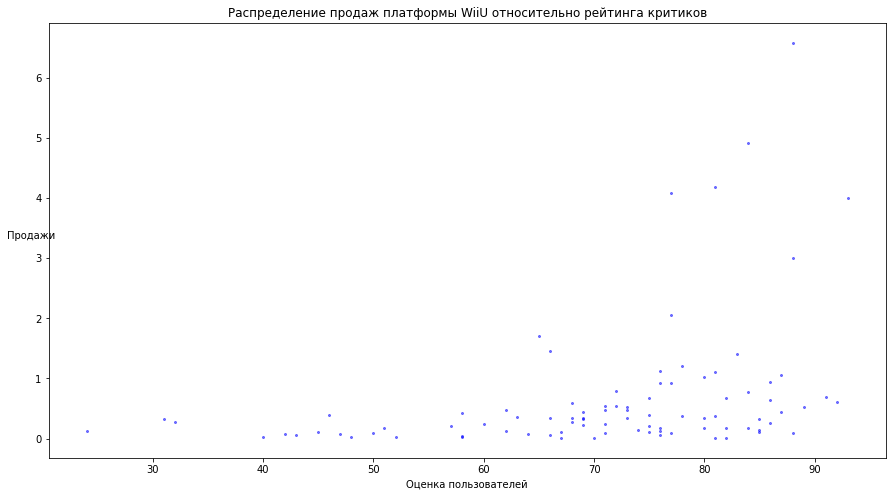

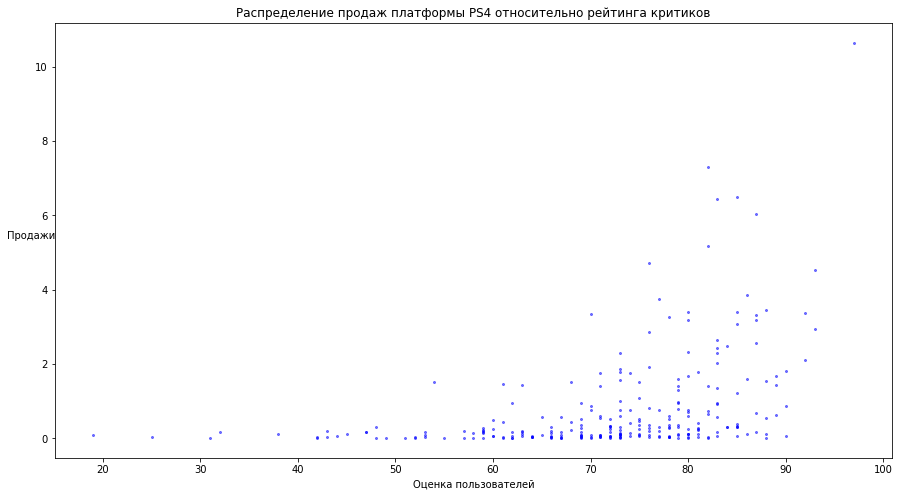

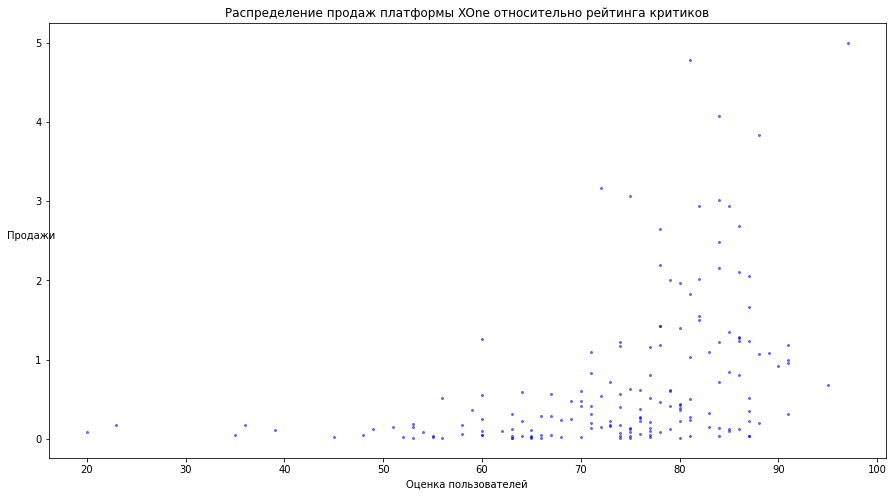

In [35]:
for type_consol in best_consol:
    df_pl_year[df_pl_year['platform'] == type_consol].plot(kind='scatter', 
        y='sales_sum' , x='critic_score', alpha=0.5, figsize=(15,8), c = 'b', s = 4)
    plt.title(f'Распределение продаж платформы {type_consol} относительно рейтинга критиков');
    plt.xlabel('Оценка пользователей');
    plt.ylabel('Продажи',rotation=0);
    plt.xticks(rotation=0);

Оценки критиков подтвердают зависимости по пользователям. Но у ктитиков всех "уделала" Сонька. Японцы, качество, ничего не поделать)

In [36]:
for type_consol in best_consol: # смотрим корреляцию
    print(df_pl_year.query('platform == @type_consol')['sales_sum']
          .corr(df_pl_year.query('platform == @type_consol')['critic_score']))
best_consol    
    

0.34706169744855475
0.40588677465201267
0.41720638309101765


0    WiiU
1     PS4
2    XOne
dtype: object

Продажи Иксбокса и Соньки умеренно зависят от рейтинга польователей. Чем выше рейтинг, тем выше продажи.
Вии несколько отстает. Находится в диапазоне от слабой до умеренной корреляции.

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='Red'>🛠 Причем тут рейтинг пользователей?</font>
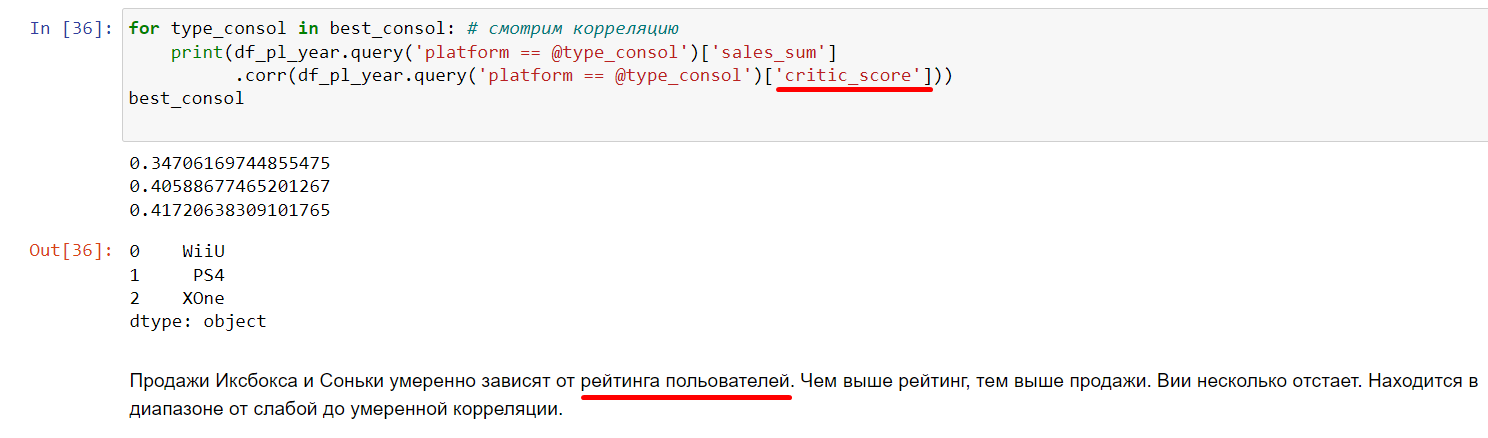

In [37]:
for type_consol in best_consol:
    print(df_pl_year.query('platform == @type_consol')['sales_sum']
          .corr(df_pl_year.query('platform == @type_consol')['user_score']))

0.3992109927499889
-0.03126053686666919
-0.06880394425598693


Вот тут более интересная картина. Вии повторяет результаты по пользователям. А тот Иксбоксу и Соьке почти пофиг на критиков. Вот что делает раскрученность бренда. 

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='Red'>🛠 Причем тут критики?</font>
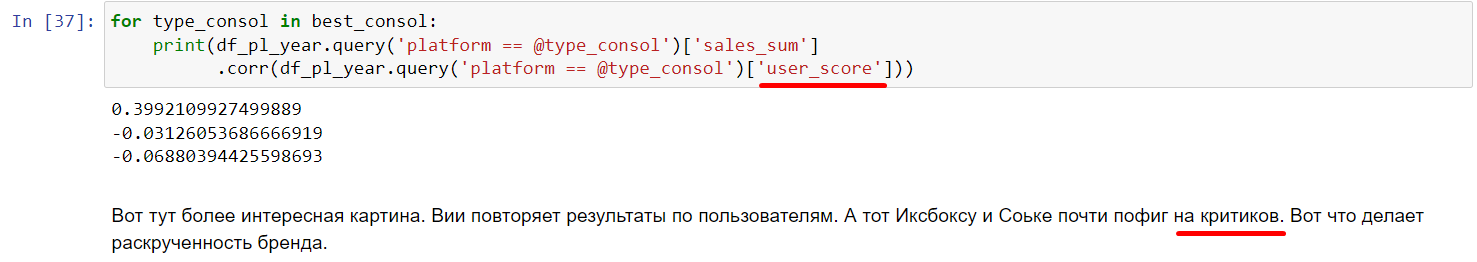

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='Red'>🛠 В задании написано: <b>Соотнесите выводы с продажами игр на других платформах.</b> А сделанно только три. Выводы, сделанные на основе диаграмм рассеяния и расчетов по нескольким платформам выглядят "весомей" и убедительней. Все платформы не надо, достаточно штук пять. Построение диаграмм рассеяния и расчет корреляции можно сделать циклом по каждой платформе и по каждому виду отзывов.</font>

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='Red'>🛠 Нет названия подраздела и не сформулирована задача.</font>

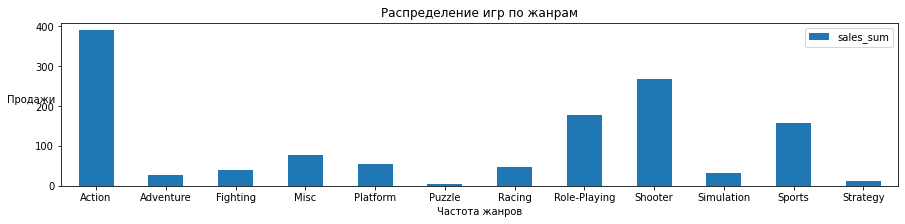

In [38]:
df_pl_year.pivot_table(index='genre', values='sales_sum' 
                        , aggfunc={"sales_sum" : 'sum'},
                        fill_value=0).plot(kind = 'bar', figsize=(15, 3)); # Смотрим распределение игр по жанрам

plt.title('Распределение игр по жанрам');
plt.xlabel('Частота жанров');
plt.ylabel('Продажи',rotation=0);
plt.xticks(rotation=0);

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkMagenta'>👉 Правильно было бы отсортировать жанры по продажам.</font>

Больше всего играют в Шутеры, Экшн-игры, Фифу или бокс. Хуже всего складывают пазлы, и стратегии. Хотя странно. стратегии довольно популярная вещь

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkMagenta'>👉 Здесь попали в ловушку, что максимальные продажи являются самыми прибыльными. Но в данных продажи по жанру для разных платформ, и если одна платформа со своей одной игрой в данном жанре выстрелила, а остальные провалились, то все равно будет виден максимум общих продаж. Но для прибыльности нужны стабильные жанры, который приносят доход не зависимо от платформы, значит на этот жанр есть устойчивый спрос.</font><br>
<font color='Red'>🛠 По этому лучше добавить сравнение медианных продаж, проиллюстрировав их диаграммами размаха и изменить промежуточные выводы.</font>

**Раздел 4. Портрет пользователя определенного региона**


Определите для пользователя каждого региона (NA, EU, JP):
Самые популярные платформы (топ-5). Опишите различия в долях продаж.
Самые популярные жанры (топ-5). Поясните разницу.
Влияет ли рейтинг ESRB на продажи в отдельном регионе?


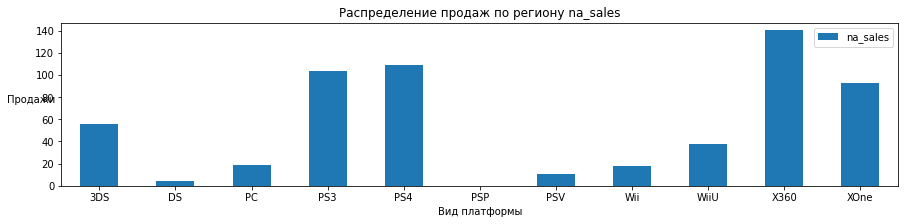

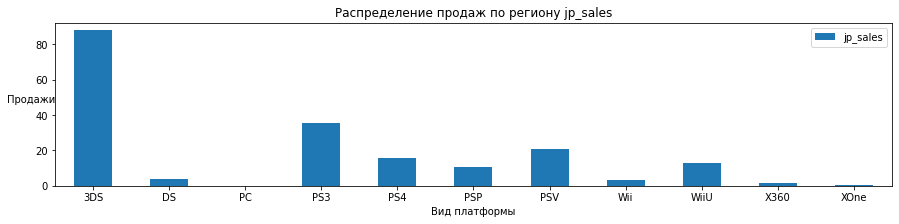

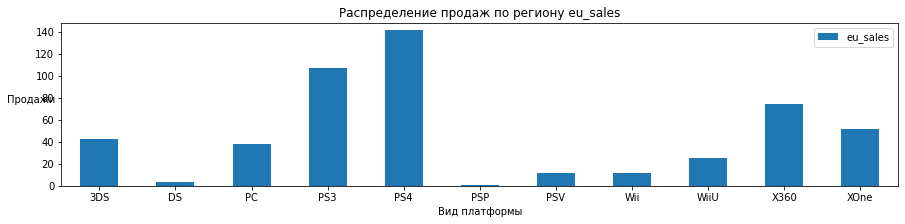

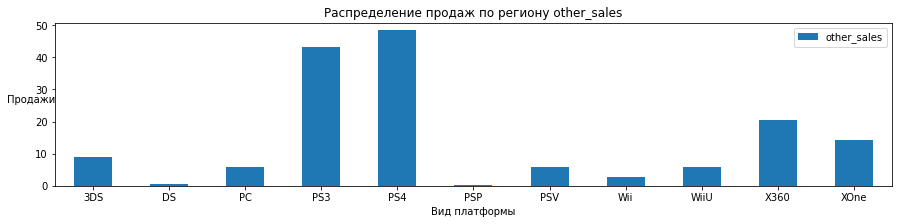

In [39]:
all_user = pd.Series(['na_sales','jp_sales','eu_sales', 'other_sales'])
for type_user in all_user:
    df_pl_year.pivot_table(index ='platform', values = type_user
                        , aggfunc={type_user : 'sum'},
                        fill_value=0).plot(kind = 'bar', figsize=(15, 3));

    plt.title(f'Распределение продаж по региону {type_user}');
    plt.xlabel(f'Вид платформы');
    plt.ylabel('Продажи',rotation=0);
    plt.xticks(rotation=0);

Почти у всех пользователей кроме японцев популярны Сонька и Иксбокс. Японцы активно поддерживают портативную версию косоли отечественного производства

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='Red'>🛠 Нет названия подраздела и не сформулирована задача.</font>

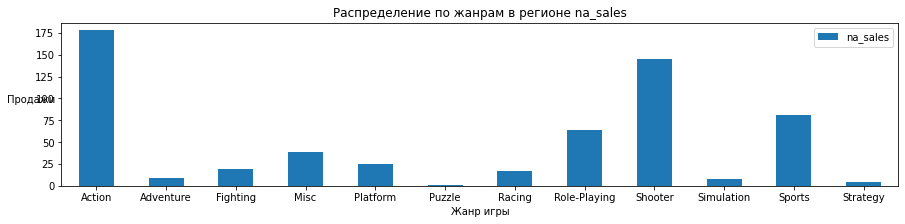

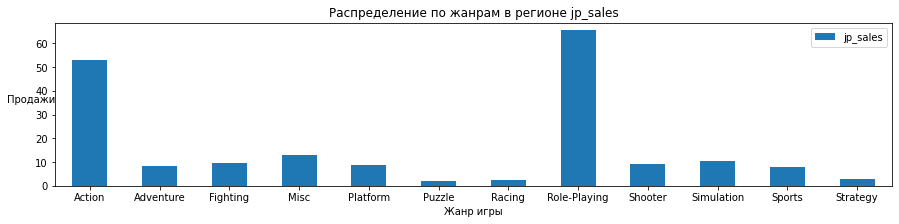

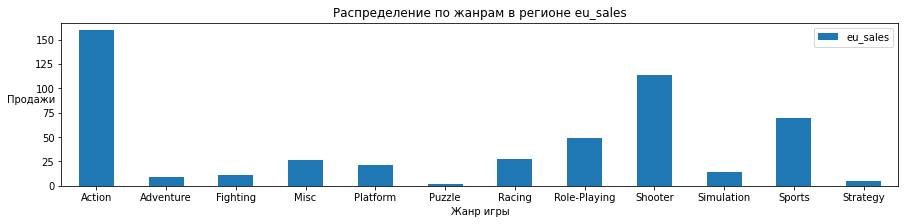

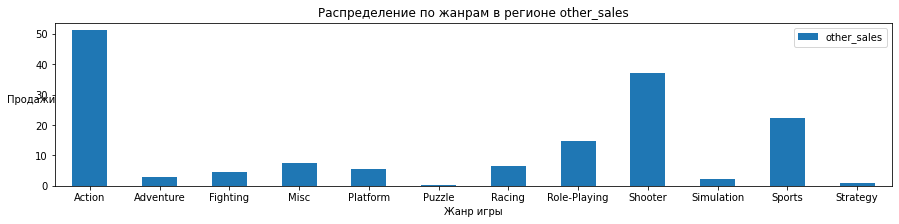

In [40]:
all_user = pd.Series(['na_sales','jp_sales','eu_sales', 'other_sales'])
for type_user in all_user:
    df_pl_year.pivot_table(index ='genre', values = type_user
                        , aggfunc={type_user : 'sum'},
                        fill_value=0).plot(kind = 'bar', figsize=(15, 3));

    plt.title(f'Распределение по жанрам в регионе {type_user}');
    plt.xlabel(f'Жанр игры');
    plt.ylabel('Продажи',rotation=0);
    plt.xticks(rotation=0);

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkMagenta'>👉 В задании просят сделать анализ по топ-5. И лучше визуализировать круговой диаграммой, только продажи платформ/жанров не вошедших в топ, собрать в одной группе, например "Другие", и по платформам, и по жанрам. Тогда на круговых диаграммах хорошо видны все региональные рынки игр с разбиением на платформы/жанры. Какая платформа/жанр занимает какую долю рынка. Тогда визуализация несет определенную бизнес-логику, связанную именно с долями рынка занимаемыми платформами/жанрами. А этого не дают другие виды диаграмм. Примерно вот так:</font>
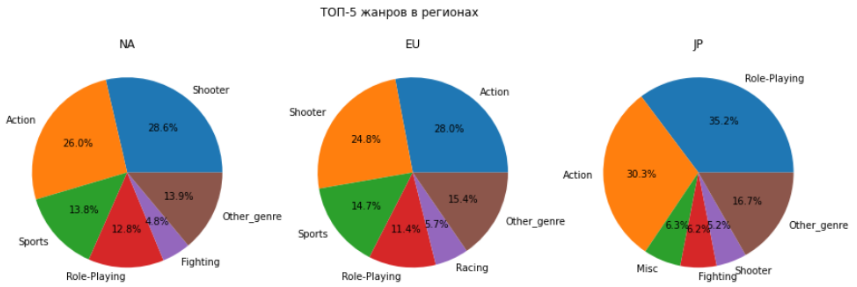

Экшн игры любят на всех континентах. Японцы любят Ролевые игры (хз что это, Симс, наверное, может еще чего, я не знаю). Все остальне любят Фифу и Шутеры.

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='Red'>🛠 Нет названия подраздела и не сформулирована задача.</font>

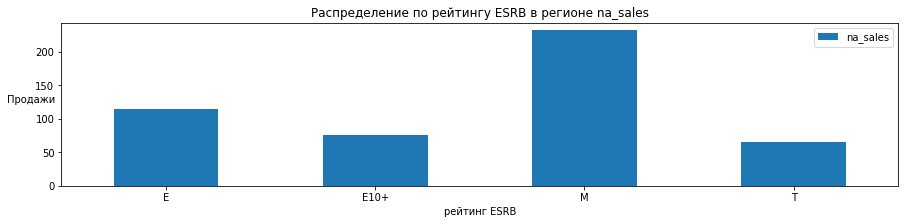

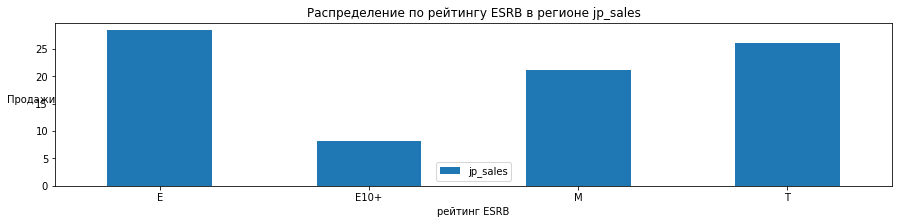

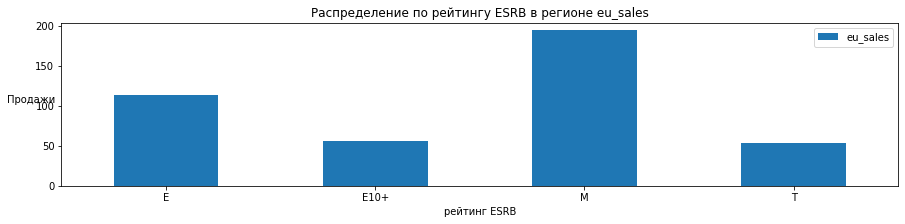

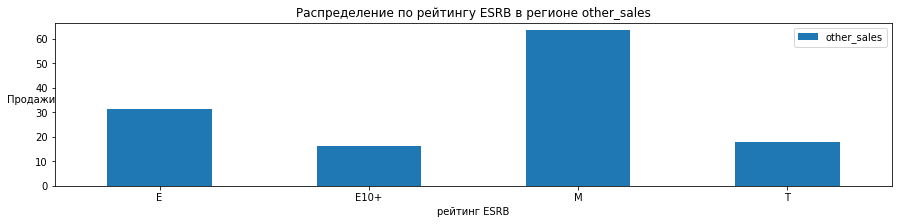

In [41]:
all_user = pd.Series(['na_sales','jp_sales','eu_sales', 'other_sales']) # Смотрим возрастной рейтинг в  регионе
for type_user in all_user:
    df_pl_year.pivot_table(index ='rating', values = type_user
                        , aggfunc={type_user : 'sum'},
                        fill_value=0).plot(kind = 'bar', figsize=(15, 3));

    plt.title(f'Распределение по рейтингу ESRB в регионе {type_user}');
    plt.xlabel(f'рейтинг ESRB');
    plt.ylabel('Продажи',rotation=0);
    plt.xticks(rotation=0);

Американцы любят игры "потяжелее" или рейтинг присваивают слишком сурово. Японцы любят покупать как с рейтингом " для всех", так и только "от 13 лет". Европейцы как американцы и как ввсе остальные.

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkMagenta'>👉 При предобработке данных не была поставлена заглушка на пропуски в рейтинге ESRB. И игры без рейтинга оказываются полностью исключенными из анализа. Но продажи именно этих игр могут указать на ключевое различие в регионах.</font><br>
<font color='DarkMagenta'>👉 А проблема в том, что если посмотреть в инете, что из себя представляет рейтинг ESRB, то окажется, что он предназначен для маркировки игр для США и Канады. И логично, что для других регионов он не заполняется. Наша задача смотреть шире на исходный датасет, так как за цифрами находятся реальные бизнес-процессы. И это необходимо учитывать при предобработке данных.  Для этого лучше поставить заглушку и вывести ее при анализе.</font>

In [48]:
# Комментарий ревьюера
temp = df_pl_year.copy()
print(temp.rating.isna().sum(), temp.rating.isna().sum()/len(temp))
temp.rating.value_counts()

1275 0.4417879417879418


M       498
T       412
E       395
E10+    306
Name: rating, dtype: int64

**Раздел 5. Провека гипотез**


Средние пользовательские рейтинги платформ Xbox One и PC одинаковые;



Средние пользовательские рейтинги жанров Action (англ. «действие», экшен-игры) и Sports (англ. «спортивные соревнования») разные.

Гипотеза 1. 

Нулевая гипотеза: средние пользовательские рейтинги платформ Xbox One и PC одинаковые


Альтернативная гипотеза: средние пользовательские рейтинги платформ Xbox One больше, чем РС

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='Red'>🛠 Не правильно сформулированы гипотезы.</font>

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='Red'>🛠 В задании написано: <br><b>Возьмите данные за соответствующий актуальный период. Актуальный период определите самостоятельно в результате исследования предыдущих вопросов. Основной фактор — эти данные помогут построить прогноз на 2017 год. <br>Не учитывайте в работе данные за предыдущие годы.</b> <br>После определения актуального периода дальнейший анализ должен проводиться только за этот период. Следует создать датасет с данными за актуальный период и далее проводить анализ только его.</font>

In [42]:
display(df_orig_off_filt) # подготовка данных для проверки гипотезы
df_orig_off_filt['platform'].unique()
display(df_orig_off_filt['platform'].value_counts())
display(df_orig_off_filt['user_score'].value_counts())
df_orig_off_filt['platform'].dropna()
df_orig_off_filt['user_score'].dropna()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,sales_sum
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8.0,E,74.09
1,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,32.23
2,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8.0,E,29.82
3,Wii Play,Wii,2006,Misc,13.96,9.18,2.93,2.84,58.0,6.6,E,26.07
4,New Super Mario Bros. Wii,Wii,2009,Platform,14.44,6.94,4.70,2.24,87.0,8.4,E,26.08
...,...,...,...,...,...,...,...,...,...,...,...,...
16441,Policenauts,3DO,1995,Adventure,0.00,0.00,0.06,0.00,NaN,NaN,NaN,0.06
16442,Bust-A-Move,3DO,1994,Puzzle,0.00,0.00,0.02,0.00,NaN,NaN,NaN,0.02
16443,Sotsugyou II: Neo Generation Special,3DO,1995,Simulation,0.00,0.00,0.02,0.00,NaN,NaN,NaN,0.02
16444,Sonic the Hedgehog 2 (8-bit),GG,1992,Platform,0.00,0.00,0.04,0.00,NaN,NaN,NaN,0.04


PS2     2127
DS      2121
PS3     1306
Wii     1286
X360    1232
PSP     1193
PS      1190
PC       957
GBA      811
XB       803
GC       542
3DS      512
PSV      429
PS4      392
N64      316
XOne     247
SNES     239
SAT      173
WiiU     147
2600     116
NES       98
GB        97
DC        52
GEN       29
NG        12
WS         6
SCD        6
3DO        3
TG16       2
PCFX       1
GG         1
Name: platform, dtype: int64

7.8    322
8.0    285
8.2    276
8.3    252
7.5    249
      ... 
2.3      2
0.7      2
1.1      2
9.7      1
0.0      1
Name: user_score, Length: 95, dtype: int64

0        8.0
1        8.3
2        8.0
3        6.6
4        8.4
        ... 
16201    7.7
16203    5.7
16213    8.0
16222    7.5
16228    7.0
Name: user_score, Length: 7463, dtype: float64

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkGreen'>👌 Хорошо, что отфильтровали пропуски. 👍</font>

В тесте ниже надо удалить пропуски. Ссылка https://stackoverflow.com/questions/37022888/t-test-in-scipy-with-nan-values

In [43]:
# Гипотеза 1
# задаём уровень значимости
alpha = 0.05

# средние пользовательские рейтинги платформ Xbox One
first_series = df_orig_off_filt.query('platform == "XOne"')['user_score']

# средние пользовательские рейтинги платформ PC
second_series = df_orig_off_filt.query('platform == "PC"')['user_score']

# проводим ttest для двух выборок, в качестве альтернативной используем одностороннюю гипотезу «больше»
results = st.ttest_ind(first_series, second_series, alternative='greater',nan_policy='omit')

print(f'p-value: {results.pvalue}')

# проверяем p-value
if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Нет оснований отвергнуть нулевую гипотезу')


p-value: 0.9999934810101899
Нет оснований отвергнуть нулевую гипотезу


<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='Red'>🛠 Не правильно проводится тестирование, здесь должна быть двухсторонняя гипотеза.</font>
<br><font color='Red'>🛠 Нет вывода по тестированию гипотез.</font>

Гипотеза 2. 

Нулевая гипотеза: средние пользовательские рейтинги жанров Action (англ. «действие», экшен-игры) и Sports (англ. «спортивные соревнования») одинаковые.


Альтернативная гипотеза: средние пользовательские рейтинги жанров Action (англ. «действие», экшен-игры) и Sports (англ. «спортивные соревнования») разные.


<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkGreen'>👌 Хорошо, правильно сформулированы гипотезы.</font>

In [44]:
display(df_orig_off_filt['genre'].unique()) # готовим данные
df_orig_off_filt['genre'].dropna()

array(['Sports', 'Racing', 'Misc', 'Platform', 'Fighting', 'Action',
       'Shooter', 'Simulation', 'Puzzle', 'Role-Playing', 'Adventure',
       'Strategy', nan], dtype=object)

0              Sports
1              Racing
2              Sports
3                Misc
4            Platform
             ...     
16441       Adventure
16442          Puzzle
16443      Simulation
16444        Platform
16445    Role-Playing
Name: genre, Length: 16444, dtype: object

In [45]:
# Гипотеза 2
# задаём уровень значимости
alpha = 0.05

# средние пользовательские рейтинги платформ Xbox One
first_series = df_orig_off_filt.query('genre == "Action"')['user_score']

# средние пользовательские рейтинги платформ PC
second_series = df_orig_off_filt.query('platform == "PC"')['user_score']

# проводим ttest для двух выборок, в качестве альтернативной используем двухстороннюю гипотезу не равно
results = st.ttest_ind(first_series, second_series, alternative='two-sided',nan_policy='omit')

print(f'p-value: {results.pvalue}')

# проверяем p-value
if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Нет оснований отвергнуть нулевую гипотезу')

p-value: 0.9013857446106495
Нет оснований отвергнуть нулевую гипотезу


<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkGreen'>👌 Правильно, что для тестирования гипотез использован двусторонний t-тест.</font>
<br><font color='Red'>🛠 Нет вывода по тестированию гипотез.</font>

Гипотезы, в целом подтвердили данные с графикоф. Икс бокс , почти, так же популяен в части рейтинга как и Сонька. Вторая гипотеза подтвердила данные о сходстве Экшн игр и Фифы по популярности.

<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='DarkMagenta'>👉 Было бы правильным показать дополнительно средние пользовательские рейтинги и по платформам, и по жанрам, как иллюстрации не противоречивости наших гипотез, используя метод `.mean()`.</font><br>
<font color='Red'>🛠 Необходимо сделать выводы по данному разделу согласно заданию:<br>
<b>Поясните:<br>
Как вы сформулировали нулевую и альтернативную гипотезы;<br>
Какой критерий применили для проверки гипотез и почему.</b><br>
То есть, необходимо описать принцип формулирования нулевой и альтернативной гипотез, обосновать почему к выборкам применили t-критерий при тестировании гипотез.</font>

**Результаты исследования. Общий вывод**

Данные за предыдущие 5 лет показали, что стоит обратить внимание на три основные консоли: Сонька, Иксбокс, и Вии, а также продавать в основном Экшн-игры и Фифу. И будет счастье. 


<font color='DarkBlue'><b>Комментарий ревьюера</b></font><br>
<font color='Red'>🛠 Общий вывод относится ко всему проекту.<br>Он должен содержать развернутое резюме по всем разделам проекта: описание данных, порядок обработки аномалий, пропусков и дубликатов, предобработка данных для анализа и все этапы исследовательского анализ.<br>Это не сделано.</font><br>
<font color='DarkMagenta'>👉 Цель нашего исследования понять, на что потратить рекламный бюджет. В исследовании мы проанализировали игры с разных сторон. Логично, что рекламный отдел от нас ждет на какие платформы (2-3 штуки), с каким жанром, с каким рейтингом ESRB и в каком регионе рекламировать. Стоит ли обращать внимание на отзывы или нет. <br>У нас вся информация в проекте для этого уже есть.</font>

<font color='DarkBlue'><b>Заключительный комментарий ревьюера</b></font><br><br>
<font color='DarkGreen'>👌 Дмитрий, проект отлично структурирован и проработан.<br>Так держать и дальше!<br></font>
<font color='Red'>🛠 Что нужно, что бы сделать проект лучше:</font><br>
<font color='Red'>🛠 Графики и диаграммы необходимо оформить подписями осей и названием графика/диаграммы на русском языке. Сделать проверку явных и неявных дубликатов. В колонку общих продаж включить и другие регионы. Сделать описание причин, которые могли привести к пропускам в датасете. Переделать проект в соответствии с требованиями к оформлению проекта. Определить характерный срок появления новых и исчезания старых платформ. Сделать выводы по п.2 шага 3 Инструкции. Выбрать несколько потенциально прибыльных платформ. Переделать построение графика «ящик с усами» по глобальным продажам игр в разбивке по платформам. Анализ влияния отзывов на продажи надо провести по нескольким платформам. В анализе игр по жанрам надо проанализировать медианные значения продаж, построив диаграммы размаха. Анализ проводить только за актуальный период. Необходимо правильно сформулировать гипотезы в тесте платформ. Переделать тестирование гипотез по платформам. Сформулировать выводы тестов гипотез. Необходимо сделать пояснения по разделу гипотез согласно заданию. Написать общий вывод исследования.<br>Обращаю внимание, что <b>все</b> графики/диаграммы проекта должны быть оформлены подписями осей и названиями на русском языке. После исправления ошибок необходимо будет откорректировать выводы анализа.</font><br>
<font color='DarkMagenta'>👉 При исправлении ошибок и недочетов будут приобретены дополнительный опыт и навыки!</font><br>
<font color='DarkGreen'>👌 Жду окончательный вариант! Успехов.</font>